In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import joblib
from joblib import dump
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [101]:
data = pd.read_csv("hantavirus_clinical.csv")
data.describe(include='all')

,syndrome,virus_strain,country_iso3,age_group,gender,incubation_days,severity,hospital_days,icu_admission,icu_days,...,hypotension,pulmonary_edema,thrombocytopenia,back_pain,abdominal_pain,blurred_vision,petechiae,oliguria,proteinuria,hemorrhage
count,7538,7538,7538,7538,7538,7538.000000,7538,7538.000000,7538.000000,7538.000000,...,2620.000000,2620.000000,2620.000000,4918.000000,4918.000000,4918.000000,4918.000000,4918.000000,4918.000000,4918.000000
unique,2,9,14,5,2,NaN,4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,HFRS,Puumala,KOR,45-59,Female,NaN,Moderate,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4918,1425,1064,1625,3884,NaN,2669,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,20.412046,NaN,10.460069,0.497214,3.302733,...,0.662595,0.641221,0.641603,0.642741,0.649044,0.637251,0.651688,0.652704,0.651688,0.652704
std,NaN,NaN,NaN,NaN,NaN,8.065180,NaN,6.184639,0.500025,4.155514,...,0.472914,0.479734,0.479621,0.479241,0.477318,0.480842,0.476484,0.476159,0.476484,0.476159
min,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,14.000000,NaN,6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,9.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,NaN,NaN,NaN,NaN,NaN,26.000000,NaN,15.000000,1.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


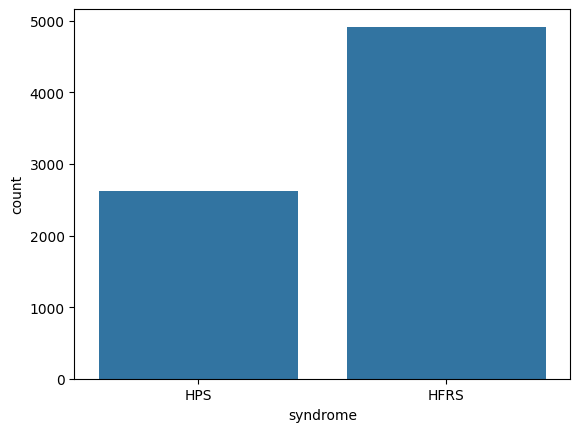

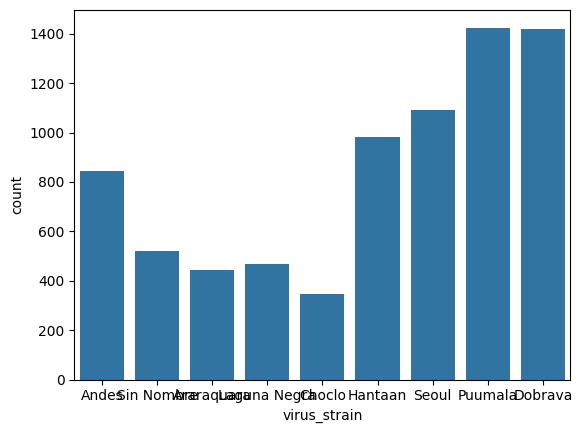

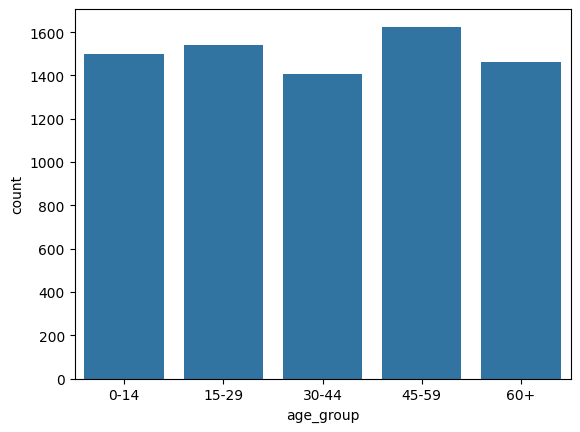

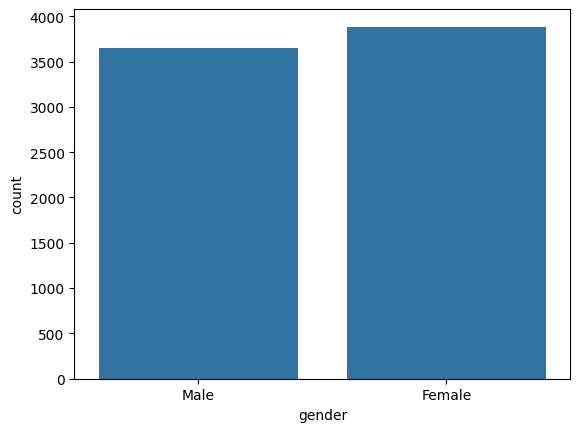

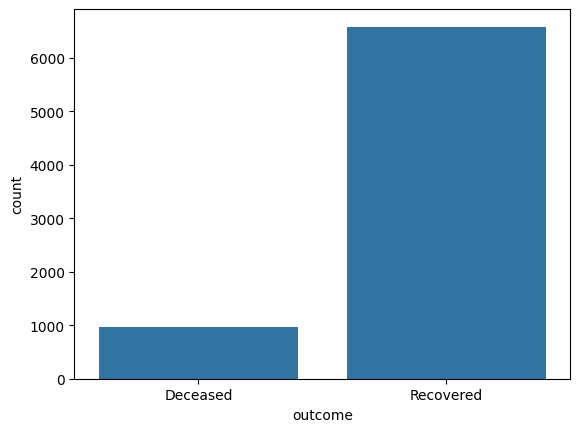

In [102]:
sb.countplot(x = data['syndrome'])
plt.show()

sb.countplot(x = data['virus_strain'])
plt.show()

sb.countplot(x = data['age_group'])
plt.show()

sb.countplot(x = data['gender'])
plt.show()

sb.countplot(x = data['outcome'])
plt.show()



In [103]:
gender_mapping = dict(enumerate(data['gender'].astype('category').cat.categories))
syndrome_mapping = dict(enumerate(data['syndrome'].astype('category').cat.categories))
virus_mapping = dict(enumerate(data['virus_strain'].astype('category').cat.categories))
age_mapping = dict(enumerate(data['age_group'].astype('category').cat.categories))

print("GenderCodes:", gender_mapping)
print("Syndrome Codes:", syndrome_mapping)
print("Virus Strain Codes:", virus_mapping)
print("Age Group Codes:", age_mapping)

GenderCodes: {0: 'Female', 1: 'Male'}
Syndrome Codes: {0: 'HFRS', 1: 'HPS'}
Virus Strain Codes: {0: 'Andes', 1: 'Araraquara', 2: 'Choclo', 3: 'Dobrava', 4: 'Hantaan', 5: 'Laguna Negra', 6: 'Puumala', 7: 'Seoul', 8: 'Sin Nombre'}
Age Group Codes: {0: '0-14', 1: '15-29', 2: '30-44', 3: '45-59', 4: '60+'}


In [104]:
data['syndrome'] = data['syndrome'].astype('category').cat.codes
data['virus_strain'] = data['virus_strain'].astype('category').cat.codes
data['gender'] = data['gender'].astype('category').cat.codes
data['age_group'] = data['age_group'].astype('category').cat.codes

scaler = MinMaxScaler()
data['incubation_days'] = scaler.fit_transform(data[['incubation_days']])
removeX = ['severity', 'hospital_days', 'icu_admission', 'icu_days', 'ventilator_used', 'country_iso3']

X = data.drop(columns=['outcome'] + removeX)
y = data['outcome']

In [105]:
xTrain, xTest, yTrain, yTest = train_test_split(X,y, test_size=0.3, random_state=2077)

model = RandomForestClassifier().fit(xTrain, yTrain)
ypred = model.predict(xTest)
print(classification_report(ypred, yTest))

              precision    recall  f1-score   support

    Deceased       0.06      0.32      0.10        57
   Recovered       0.98      0.87      0.92      2205

    accuracy                           0.86      2262
   macro avg       0.52      0.60      0.51      2262
weighted avg       0.96      0.86      0.90      2262



In [108]:
joblib.dump(model, 'hantavirusmodel.joblib')
joblib.dump(list(X.columns), 'model_features.joblib')

['model_features.joblib']